# [Demo] Controle de fluxo (conditional edges)

Até aqui, toda aresta levava sempre ao mesmo lugar. Agora uma aresta decide o próximo nó em tempo de
execução, de acordo com o estado. É assim que a Clínica Alura ganha um fluxo de triagem de verdade.

O que vamos ver:
- um nó classificador com saída estruturada (`with_structured_output`);
- `add_conditional_edges` para rotear entre três caminhos;
- convenções de nomeação de nós e arestas;
- o `create_agent` por dentro, e o mesmo ciclo ReAct construído na mão com `ToolNode`.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from typing import Literal
from pydantic import BaseModel
from IPython.display import Image, display
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## Um nó classificador

O primeiro nó lê a mensagem do paciente e devolve a intenção. Em vez de pedir uma palavra solta e recortar
o texto na mão, usamos `with_structured_output` com um modelo Pydantic, a mesma ferramenta de validação
que já vimos: o próprio contrato de saída garante que a intenção seja uma das três opções.

In [4]:
class TriageState(MessagesState):
    intent: str

In [5]:
class IntentClassification(BaseModel):
    intent: Literal["informação", "agendamento", "urgência"]

In [6]:
classifier = model.with_structured_output(IntentClassification)

In [7]:
def classify(state: TriageState) -> dict:
    instruction = SystemMessage("Classifique a mensagem do paciente: informação, agendamento ou urgência.")
    message = state["messages"][-1]
    result = classifier.invoke([instruction, message])
    return {"intent": result.intent}

## Os nós de resposta

Cada caminho termina num nó só. `info` e `scheduling` respondem normalmente; `urgent` é diferente: não
precisa de mais nenhuma chamada de modelo, só encaminha para atendimento humano e encerra ali.

In [8]:
def info(state: TriageState) -> dict:
    return {"messages": [AIMessage("Claro, posso te passar essa informação.")]}

In [9]:
def scheduling(state: TriageState) -> dict:
    return {"messages": [AIMessage("Vamos seguir com o agendamento.")]}

In [10]:
def urgent(state: TriageState) -> dict:
    return {"messages": [AIMessage("Isso parece urgente. Estou te encaminhando para atendimento humano agora.")]}

In [11]:
builder = StateGraph(TriageState)
builder.add_node("classify", classify)
builder.add_node("info", info)
builder.add_node("scheduling", scheduling)
builder.add_node("urgent", urgent)

## Roteando com add_conditional_edges

Uma função de roteamento conhece os dois lados: o valor que `classify` produz e o nome do nó que deve
rodar a seguir. Ela é o único lugar que traduz um pro outro; nem `classify` nem os nós de resposta
precisam saber nada sobre o nome uns dos outros.

In [12]:
def router_fn(state: TriageState) -> Literal["info", "scheduling", "urgent"]:
    if state["intent"] == "informação":
        return "info"
    elif state["intent"] == "agendamento":
        return "scheduling"
    else:
        return "urgent"

In [13]:
builder.add_edge(START, "classify")
builder.add_conditional_edges(
    source="classify", 
    path=router_fn,
)
builder.add_edge("info", END)
builder.add_edge("scheduling", END)
builder.add_edge("urgent", END)

In [14]:
graph = builder.compile()

O grafo agora se ramifica: a partir de `classify`, três destinos possíveis.

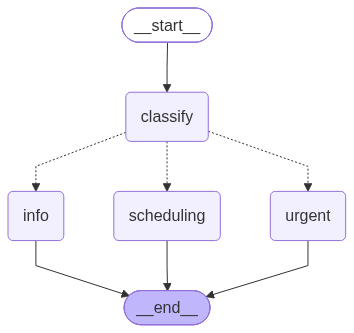

In [15]:
display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [16]:
response = graph.invoke({"messages": [HumanMessage("Vocês atendem cardiologia?")]})
print(response["intent"], ":", response["messages"][-1].content)

informação : Claro, posso te passar essa informação.


In [17]:
response = graph.invoke({"messages": [HumanMessage("Quero marcar uma consulta de dermatologia")]})
print(response["intent"], ":", response["messages"][-1].content)

agendamento : Vamos seguir com o agendamento.


In [18]:
response = graph.invoke({"messages": [HumanMessage("Estou com uma dor forte no peito, o que eu faço?")]})
print(response["intent"], ":", response["messages"][-1].content)

urgência : Isso parece urgente. Estou te encaminhando para atendimento humano agora.


## Nomeando nós e arestas

Nomes de nó são verbos ou ações (`classify`, `scheduling`): o que aquela etapa faz. Valores de roteamento
são os próprios dados que a função de roteamento devolve (`"informação"`, `"urgência"`): o que o estado
diz que deve acontecer. Misturar os dois deixa o `add_conditional_edges` mais difícil de ler.

## O create_agent por dentro

O `create_agent` que já usamos usa exatamente esse mecanismo: uma aresta condicional decidindo, a
cada passo, entre chamar uma tool ou responder e encerrar.

In [19]:
@tool
def find_available_slots(specialty: str, date: str) -> str:
    """Horários livres na agenda da Clínica Alura para a especialidade e data (YYYY-MM-DD)."""
    schedule = {"cardiologia": ["09:00", "10:30"], "dermatologia": ["14:00"]}
    slots = schedule.get(specialty.lower(), [])
    return f"Horários para {specialty} em {date}: {', '.join(slots) or 'nenhum'}"

In [20]:
agent = create_agent(
    model=model,
    tools=[find_available_slots],
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.",
)

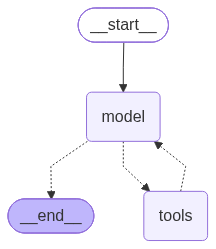

In [21]:
display(Image(agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

A aresta que sai do nó de modelo é condicional: para `tools` quando o modelo pede uma chamada, para `END`
quando ele responde direto. `LangChain` monta esse `add_conditional_edges` para você; o mecanismo por
baixo é o mesmo que acabamos de construir na mão.

## Construindo o mesmo grafo na mão

O LangGraph já traz um nó pronto para rodar tools: `ToolNode`. Com ele, dá para montar o ciclo ReAct
inteiro sem o `create_agent`, com as mesmas peças que já usamos até aqui: um `StateGraph`, uma aresta
condicional e `add_edge`.

In [22]:
model_with_tools = model.bind_tools([find_available_slots])

In [23]:
tool_node = ToolNode([find_available_slots])

In [24]:
def call_model(state: MessagesState) -> dict:
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [25]:
def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [26]:
manual_builder = StateGraph(MessagesState)
manual_builder.add_node("model", call_model)
manual_builder.add_node("tools", tool_node)

In [27]:
manual_builder.add_edge(START, "model")
manual_builder.add_conditional_edges("model", should_continue)
manual_builder.add_edge("tools", "model")

In [28]:
manual_agent = manual_builder.compile()

Mesmo formato do grafo do `create_agent`: `model` decide entre `tools` e `END`, `tools` volta para `model`.

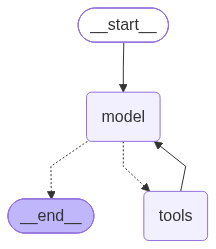

In [29]:
display(Image(manual_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [30]:
response = manual_agent.invoke({"messages": [HumanMessage("Tem cardiologia dia 2026-07-20?")]})
print(response["messages"][-1].content)

Sim, há horários disponíveis para cardiologia no dia 20 de julho de 2026. Os horários disponíveis são às 09:00 e 10:30.


## Takeaway

`add_conditional_edges` transforma o estado em decisão de rota, na mão ou por dentro do `create_agent`.
Com `ToolNode` e uma função de roteamento, o ciclo ReAct inteiro sai do "cofre" do `create_agent` e vira
código que dá para ler, testar e modificar.